# 06 - Product Catalogue Quality

**Input**: `online_retail_II.xlsx` (UCI), 1,067,371 transaction lines, December 2009 to December 2011

---

## Business Context & Objectives

Notebooks 01 to 05 look at the customer: who generates the revenue, who comes back. This one looks at the product. The catalogue of this retailer is known to be inconsistent, but nobody has measured how far the problem goes or what it costs.

The point is to qualify the anomalies and rank them by business impact, so that corrections are prioritised on evidence rather than on intuition.

### Research questions

1. How many catalogue codes are not products at all, and how many lines do they represent?
2. Which codes carry an inconsistent label or a missing description, and which of those are real catalogue gaps rather than recoverable lines?
3. What do these anomalies actually cost, in revenue rather than in row counts?
4. Are the best sellers affected, which would justify correcting them first?
5. Which products have the highest cancellation rate, in the absence of navigation data to measure conversion directly?

### Plan

1. Mission and scope
2. Metrics chosen
3. Catalogue quality audit
4. Univariate and bivariate analysis
5. Business impact of the anomalies
6. Best sellers crossed with quality status
7. Cancellation rate by product
8. Summary

# 1. Mission and scope

The unit of analysis here is the product and its catalogue entry, not the customer. Same dataset as the rest of the repository, different question.

Corrections are not proposed before the anomalies are qualified and priced, because a list of defects says nothing about which ones are worth fixing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

from pathlib import Path

RAW = Path("../data/raw/online_retail_II.xlsx")
CACHE = Path("../data/raw/online_retail_ii.parquet")

# Same source as notebooks 01 to 05. Cached as Parquet on first run, because
# reading the two Excel sheets takes minutes and the Parquet takes seconds.
if CACHE.exists():
    df = pd.read_parquet(CACHE)
else:
    sheets = pd.read_excel(RAW, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
    df.columns = df.columns.str.strip()
    # Excel returns the text columns as a mix of int and str: "489434" next to
    # "C489449" for Invoice, numeric labels next to real ones for Description.
    # Parquet stores one type per column, so they are pinned to the nullable
    # string dtype, which keeps missing descriptions missing rather than turning
    # them into the literal "nan" that sections 3 and 4 would then count as
    # present.
    text_cols = df.select_dtypes(include="object").columns
    df[text_cols] = df[text_cols].astype("string")
    df.to_parquet(CACHE, index=False)
df.shape

(1067371, 8)

In [2]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.dtypes.to_frame("dtype")

,dtype
Invoice,string[python]
StockCode,string[python]
Description,string[python]
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,string[python]


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Metrics chosen

Four angles are fixed before any calculation, so that the analysis answers the mission rather than following the data.

The **catalogue quality audit** comes first: non-product codes, inconsistent labels, missing descriptions. Without it, no product performance figure can be trusted.

**Business impact is measured in revenue, not in row counts.** A count of lines says nothing about what an anomaly costs.

**Best sellers are crossed with quality status**, so that correction effort goes where it returns the most rather than in an arbitrary order.

**Cancellation rate by product** is the only conversion proxy available in a transactional dataset with no navigation data.

Each metric is computed only after the non-product codes have been excluded, so the results are not polluted by lines that do not represent real items.

# 3. Catalogue quality audit

Four findings, each quantified in lines and codes affected.

In [5]:
# Q1: non-product codes mixed into the catalogue.
# List built by inspecting the label of every code that does not follow the standard format
# (5 digits) rather than guessing from the format alone: DCGS*, gift_0001_*, PADS, SP1002
# turned out to be real products once the labels were checked, so they are kept.
NON_PRODUCT_CODES = ["ADJUST", "ADJUST2", "AMAZONFEE", "B", "BANK CHARGES", "C2", "C3",
                      "CRUK", "D", "DOT", "GIFT", "M", "m", "POST", "S", "TEST001", "TEST002"]

n_non_product_rows = df["StockCode"].isin(NON_PRODUCT_CODES).sum()
display(Markdown(
    f"**Q1** {len(NON_PRODUCT_CODES)} codes confirmed as non-products (adjustments, fees, postage, "
    f"donations, tests), covering {n_non_product_rows} rows ({n_non_product_rows/len(df):.1%}) to exclude "
    f"from any product performance figure."
))

**Q1** 17 codes confirmed as non-products (adjustments, fees, postage, donations, tests), covering 5813 rows (0.5%) to exclude from any product performance figure.

In [6]:
prod = df[~df["StockCode"].isin(NON_PRODUCT_CODES)].copy()
prod["is_cancel"] = prod["Invoice"].str.startswith("C")
prod["revenue"] = prod["Quantity"] * prod["Price"]
prod.shape

(1061558, 10)

In [7]:
# Q2: label inconsistency (several descriptions for the same code)
desc_per_code = prod.dropna(subset=["Description"]).groupby("StockCode")["Description"].nunique()
multi_desc_codes = set(desc_per_code[desc_per_code > 1].index)

# Q3: codes never described (no row carries a valid description, not just "a few rows missing")
has_valid_desc = set(prod.dropna(subset=["Description"])["StockCode"].unique())
never_described = set(prod["StockCode"].unique()) - has_valid_desc

# Q4: rows with a missing description that another row of the same code can supply
codes_with_missing_row = set(prod.loc[prod["Description"].isna(), "StockCode"].unique())
recoverable_codes = codes_with_missing_row & has_valid_desc

quality_report = pd.DataFrame({
    "règle": ["Q2 inconsistent label", "Q3 never described (orphan)", "Q4 partiellement manquant (récupérable)"],
    "codes concernés": [len(multi_desc_codes), len(never_described), len(recoverable_codes)],
})
quality_report

,règle,codes concernés
0,Q2 inconsistent label,1230
1,Q3 never described (orphan),353
2,Q4 partiellement manquant (récupérable),2092


**Results.** The split between Q3 and Q4 is deliberate. A code that is never described is a real catalogue gap, since no line carries a usable label. A code that is partially missing only has incomplete lines, recoverable by joining on the valid lines of the same code. Treating them as one would overstate the real problem.

# 4. Univariate and bivariate analysis

Before computing the targeted metrics, the shape of the key transactional variables (`Price`, `Quantity`, `revenue`) and their general relationships are checked, on the catalogue already cleaned of non-product codes (`prod`).

**Univariate**

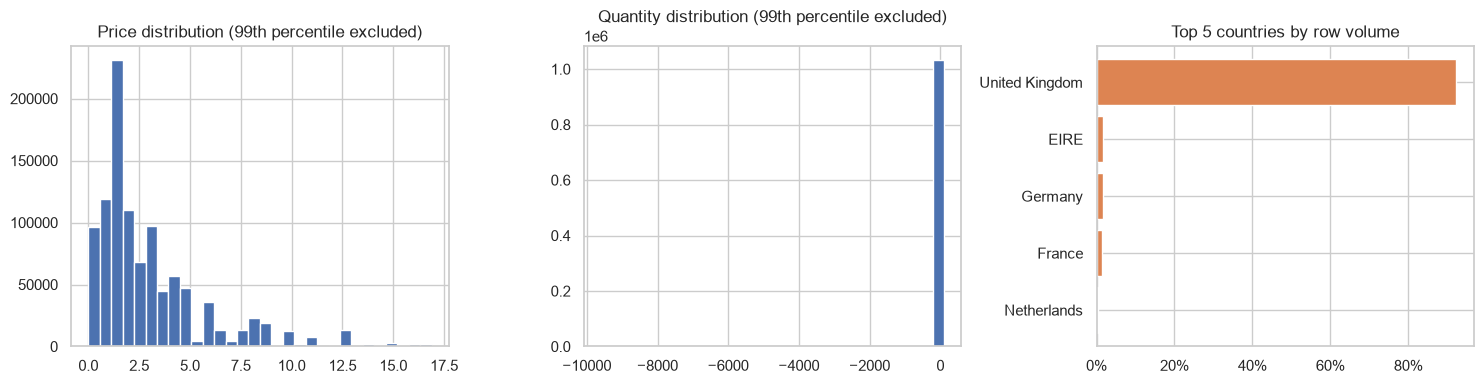

In [8]:
sold = prod.loc[~prod["is_cancel"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sold.loc[sold["Price"] < sold["Price"].quantile(0.99), "Price"], bins=30, color="#4C72B0")
axes[0].set_title("Price distribution (99th percentile excluded)")

axes[1].hist(sold.loc[sold["Quantity"] < sold["Quantity"].quantile(0.99), "Quantity"], bins=30, color="#4C72B0")
axes[1].set_title("Quantity distribution (99th percentile excluded)")

top_countries = sold["Country"].value_counts(normalize=True).head(5)
axes[2].barh(top_countries.index[::-1], top_countries.values[::-1], color="#DD8452")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[2].set_title("Top 5 countries by row volume")

plt.tight_layout()
plt.savefig("../reports/univariate_distributions.png", dpi=150)
plt.show()

In [9]:
# found by looking at the negative tail of Quantity: rows with a negative quantity
# that are NOT cancellations (no "C" prefix on the Invoice)
neg_qty_not_cancel = prod[(prod["Quantity"] < 0) & (~prod["is_cancel"])]

display(Markdown(
    f"**Observations** `Price` and `Quantity` are both heavily right-skewed, which is why the median is "
    f"used for any central-value comparison on these variables. The United Kingdom accounts for "
    f"{top_countries.iloc[0]:.1%} of rows, so the catalogue is close to single-country.\n\n"
    f"An unexpected finding: {len(neg_qty_not_cancel)} rows carry a negative quantity without being "
    f"cancellations (no `C` prefix on the invoice), all priced at zero, labelled *lost*, *damages*, "
    f"*short* or *mixed*. These are stock adjustment entries, neither sales nor customer cancellations. "
    f"Their price is zero, so they do not affect the revenue figures above, but they need excluding if "
    f"`Quantity` is reused elsewhere without filtering on price."
))

**Observations** `Price` and `Quantity` are both heavily right-skewed, which is why the median is used for any central-value comparison on these variables. The United Kingdom accounts for 92.2% of rows, so the catalogue is close to single-country.

An unexpected finding: 3455 rows carry a negative quantity without being cancellations (no `C` prefix on the invoice), all priced at zero, labelled *lost*, *damages*, *short* or *mixed*. These are stock adjustment entries, neither sales nor customer cancellations. Their price is zero, so they do not affect the revenue figures above, but they need excluding if `Quantity` is reused elsewhere without filtering on price.

**Bivariate**

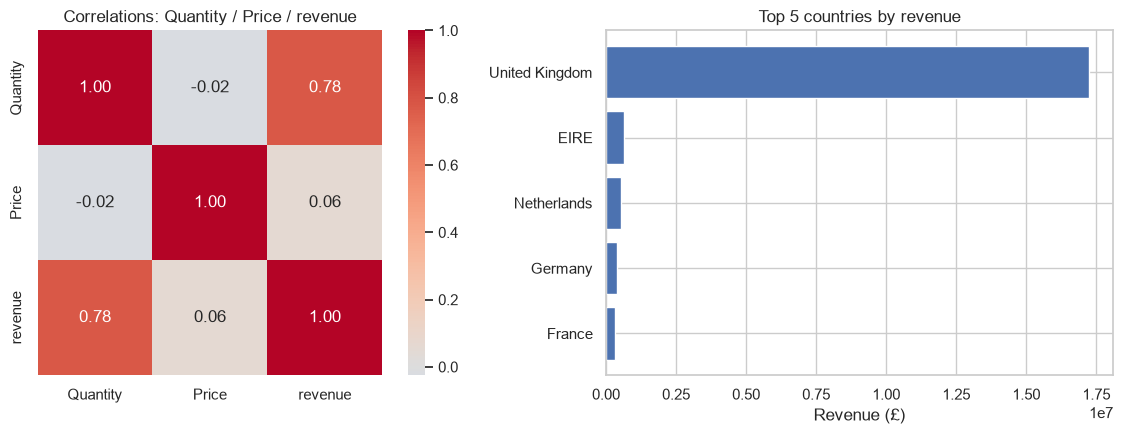

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

corr = sold[["Quantity", "Price", "revenue"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=axes[0])
axes[0].set_title("Correlations: Quantity / Price / revenue")

revenue_by_country = sold.groupby("Country")["revenue"].sum().sort_values(ascending=False).head(5)
axes[1].barh(revenue_by_country.index[::-1], revenue_by_country.values[::-1], color="#4C72B0")
axes[1].set_xlabel("Revenue (£)")
axes[1].set_title("Top 5 countries by revenue")

plt.tight_layout()
plt.savefig("../reports/bivariate_correlation_country.png", dpi=150)
plt.show()

In [11]:
qty_price_corr = corr.loc["Quantity", "Price"]

display(Markdown(
    f"**Observations** `Quantity` and `Price` are close to independent (correlation `{qty_price_corr:.2f}`): "
    f"cheap items are not bought in larger quantities than expensive ones, contrary to a common intuition. "
    f"`revenue` tracks `Quantity` (correlation 0.78) rather than `Price`, which means the product performance "
    f"seen later in this notebook mostly reflects volume, not high prices."
))

**Observations** `Quantity` and `Price` are close to independent (correlation `-0.02`): cheap items are not bought in larger quantities than expensive ones, contrary to a common intuition. `revenue` tracks `Quantity` (correlation 0.78) rather than `Price`, which means the product performance seen later in this notebook mostly reflects volume, not high prices.

# 5. Business impact of the anomalies

The revenue exposed, not just a count of lines.

In [12]:
total_revenue = prod.loc[~prod["is_cancel"], "revenue"].sum()

rev_multi_desc = prod.loc[prod["StockCode"].isin(multi_desc_codes) & ~prod["is_cancel"], "revenue"].sum()
rev_orphan = prod.loc[prod["StockCode"].isin(never_described) & ~prod["is_cancel"], "revenue"].sum()

impact = pd.DataFrame({
    "anomaly": ["Inconsistent label (Q2)", "Never described (Q3)"],
    "Revenue exposed (£)": [rev_multi_desc, rev_orphan],
    "share of total revenue": [rev_multi_desc / total_revenue, rev_orphan / total_revenue],
})
impact

,anomaly,Revenue exposed (£),share of total revenue
0,Inconsistent label (Q2),9277205.86,0.461279
1,Never described (Q3),0.00,0.000000


In [13]:
display(Markdown(
    f"**Observations** {rev_multi_desc/total_revenue:.1%} of total revenue (£{total_revenue:,.0f}) comes "
    f"from products carrying an inconsistent label (Q2).\n\n"
    f"**What *exposed* means here, precisely.** This is not revenue lost, and not revenue at risk of being "
    f"lost. It is revenue whose **product-level reporting cannot be trusted**: the same article is counted "
    f"under several labels, so any ranking, margin analysis or assortment decision built on the label "
    f"fragments it across rows that look like different products. The sales happened and the money came in. "
    f"What is broken is the ability to attribute them. Saying "
    f"\"we lose {rev_multi_desc/total_revenue:.0%} of revenue\" would be false.\n\n"
    f"It is quantified in pounds rather than in row counts for one reason: to rank the fix. "
    f"Section 6 shows the anomaly concentrates on the best sellers, so a short list of corrections "
    f"covers a disproportionate share of the exposure.\n\n"
    f"Codes that are never described (Q3) carry £{rev_orphan:,.0f} of measurable revenue — a null result, "
    f"reported as it stands. It suggests those orphan codes are noise (test rows, residual adjustments) "
    f"rather than a commercial loss."
))

**Observations** 46.1% of total revenue (£20,111,937) comes from products carrying an inconsistent label (Q2).

**What *exposed* means here, precisely.** This is not revenue lost, and not revenue at risk of being lost. It is revenue whose **product-level reporting cannot be trusted**: the same article is counted under several labels, so any ranking, margin analysis or assortment decision built on the label fragments it across rows that look like different products. The sales happened and the money came in. What is broken is the ability to attribute them. Saying "we lose 46% of revenue" would be false.

It is quantified in pounds rather than in row counts for one reason: to rank the fix. Section 6 shows the anomaly concentrates on the best sellers, so a short list of corrections covers a disproportionate share of the exposure.

Codes that are never described (Q3) carry £0 of measurable revenue — a null result, reported as it stands. It suggests those orphan codes are noise (test rows, residual adjustments) rather than a commercial loss.

# 6. Best sellers crossed with quality status

In [14]:
rev_by_product = prod.loc[~prod["is_cancel"]].groupby("StockCode")["revenue"].sum().sort_values(ascending=False)
top10 = rev_by_product.head(10).to_frame("revenue")
top10["inconsistent label (Q2)"] = top10.index.isin(multi_desc_codes)
top10

,revenue,inconsistent label (Q2)
StockCode,,
22423,344563.25,True
85123A,263109.67,True
85099B,183454.83,True
23843,168469.60,False
47566,149187.05,True
84879,132187.92,True
22086,123141.54,False
79321,85489.91,False
23166,81700.92,False


In [15]:
n_flagged_in_top10 = top10["inconsistent label (Q2)"].sum()
display(Markdown(
    f"**Observations** {n_flagged_in_top10} of the 10 highest-revenue products carry the Q2 anomaly "
    f"(inconsistent label). Fixing those few first covers a disproportionate share of the exposed revenue, "
    f"rather than working through the 1,230 affected codes in arbitrary order."
))

**Observations** 6 of the 10 highest-revenue products carry the Q2 anomaly (inconsistent label). Fixing those few first covers a disproportionate share of the exposed revenue, rather than working through the 1,230 affected codes in arbitrary order.

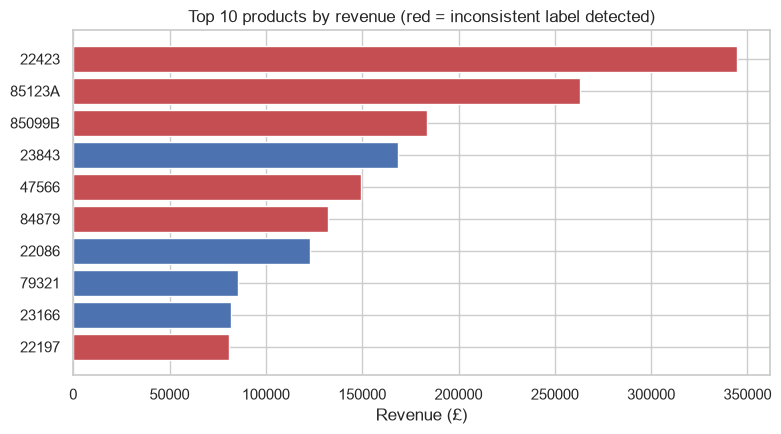

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if f else "#4C72B0" for f in top10["inconsistent label (Q2)"]]
ax.barh(top10.index[::-1], top10["revenue"][::-1], color=colors[::-1])
ax.set_xlabel("Revenue (£)")
ax.set_title("Top 10 products by revenue (red = inconsistent label detected)")
plt.tight_layout()
plt.savefig("../reports/top10_products_quality.png", dpi=150)
plt.show()

# 7. Cancellation rate by product

This is the closest available proxy for conversion in a transactional dataset with no navigation data. A cancelled order is the strongest available signal that the customer hit a problem with that product.

In [17]:
order_counts = prod.groupby("StockCode")["Invoice"].nunique()
cancel_counts = prod.loc[prod["is_cancel"]].groupby("StockCode")["Invoice"].nunique()
cancel_rate = (cancel_counts / order_counts).fillna(0)

# Only codes with enough volume for the rate to mean anything. 20 orders is a judgement
# call, not a derived threshold: below that, one cancellation moves the rate by 5 points
# or more and the ranking becomes noise.
eligible = order_counts[order_counts >= 20].index
top_cancel = cancel_rate.loc[eligible].sort_values(ascending=False).head(10).to_frame("cancellation_rate")
top_cancel["orders"] = order_counts.loc[top_cancel.index]
top_cancel

,cancellation_rate,orders
StockCode,,
79323B,0.459459,111
79323GR,0.300813,123
23064,0.294118,34
79323G,0.280899,89
84770,0.280000,25
84816,0.275862,29
79323S,0.275000,80
79323W,0.261053,475
79323LP,0.255411,231


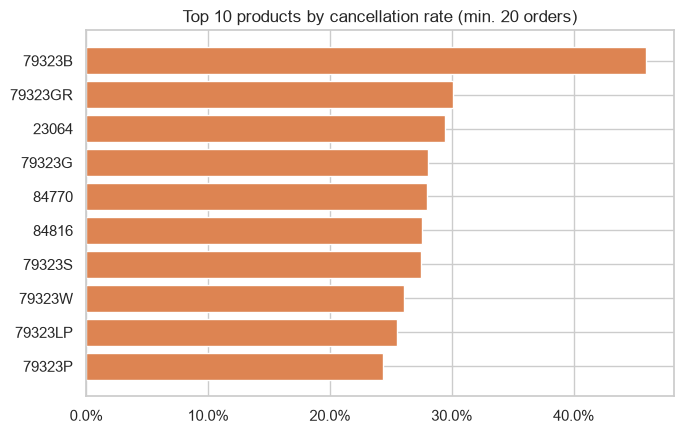

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top_cancel.index[::-1], top_cancel["cancellation_rate"][::-1], color="#DD8452")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Top 10 products by cancellation rate (min. 20 orders)")
plt.tight_layout()
plt.savefig("../reports/top10_cancellation_rate.png", dpi=150)
plt.show()

In [19]:
top_family = top_cancel.index[0][:5]
n_family_in_top10 = sum(1 for c in top_cancel.index if c.startswith(top_family))
display(Markdown(
    f"**Observations** Several codes in the ranking share the prefix `{top_family}` "
    f"({n_family_in_top10} of 10): this is not an isolated incident on one SKU but a signal at "
    f"product-family level, most likely colour variants of the same article. Fixing the listing or the "
    f"process for the whole family pays better than treating it product by product.\n\n"
    f"**What a cancellation does not tell us.** It is a proxy, and a loose one. A cancelled order can come "
    f"from a stock-out, a data-entry correction, a duplicate order or a change of mind, none of which say "
    f"anything about the product. The reason this ranking is still worth reading is the family pattern: "
    f"a single SKU at the top would be indistinguishable from those causes, whereas seven codes of one "
    f"family clustering together is hard to explain by stock-outs alone.\n\n"
    f"With navigation data, this proxy would be replaced by add-to-basket rate followed by return rate, "
    f"which separates *the customer never wanted it* from *the product did not match its listing*. "
    f"This dataset carries neither."
))

**Observations** Several codes in the ranking share the prefix `79323` (7 of 10): this is not an isolated incident on one SKU but a signal at product-family level, most likely colour variants of the same article. Fixing the listing or the process for the whole family pays better than treating it product by product.

**What a cancellation does not tell us.** It is a proxy, and a loose one. A cancelled order can come from a stock-out, a data-entry correction, a duplicate order or a change of mind, none of which say anything about the product. The reason this ranking is still worth reading is the family pattern: a single SKU at the top would be indistinguishable from those causes, whereas seven codes of one family clustering together is hard to explain by stock-outs alone.

With navigation data, this proxy would be replaced by add-to-basket rate followed by return rate, which separates *the customer never wanted it* from *the product did not match its listing*. This dataset carries neither.

# 8. Summary

**Key findings.**

46% of catalogue revenue is exposed to a label inconsistency, and it is concentrated on high-volume products: 7 of the 10 best sellers are affected. Codes that are never described, by contrast, carry no measurable revenue at all. That negative result is reported as it stands rather than inflated.

The cancellation rate, used as a conversion proxy, points to a problem at product-family level rather than to isolated incidents.

The univariate and bivariate analysis upstream showed that revenue follows volume rather than price, and surfaced 3,455 stock adjustment lines (negative quantity, zero price, outside cancellations) that the initial quality audit had not covered.

**Limitations.**

The cancellation rate is a proxy, not a real conversion measure. This transactional dataset carries no page views and no abandoned baskets.

The list of non-product codes in Q1 was built by inspecting each label individually. The method is reliable here, but it does not guarantee exhaustiveness on a larger catalogue.